# 02 - Modelado Predictivo y Evaluación

Este notebook implementa la fase de modelado CRISP-DM para predecir `finished` en F1.

## Objetivo
Comparar modelos supervisados y ensambles, seleccionar estadísticamente los mejores, optimizarlos con tres estrategias y guardar un pipeline desplegable.

## Corrección metodológica central
La validación cruzada se ejecuta sobre `train_original.csv`, no sobre `train_balanced.csv`. En cada fold se ajusta el flujo completo:

`drop_leakage -> feature_engineering -> winsorizer -> selector -> SMOTENC(sampling_strategy=0.5) -> scaler -> model`

Así se evita leakage por datos sintéticos creados antes de separar folds. El test se usa al final absoluto para estimar generalización y documentar el control de sobreajuste; no decide selección, stacking ni optimización.

## Estrategias de optimización
Para los 3 mejores modelos por CV se aplican:

1. `GridSearchCV`: búsqueda exhaustiva en grillas pequeñas y reproducibles.
2. Optuna: optimización bayesiana TPE.
3. `GASearchCV`: algoritmo genético sobre espacios continuos, enteros y categóricos.


In [1]:
from pathlib import Path
import json
import pickle
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy import stats
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous, Categorical, Integer
import optuna
from xgboost import XGBClassifier

ROOT = Path.cwd().resolve()
if not (ROOT / 'app').exists() and (ROOT.parent / 'app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.f1_pipeline import (
    DEFAULT_SELECTED_FEATURES,
    FeatureEngineer,
    LeakageColumnDropper,
    ColumnSelector,
    Winsorizer,
    smotenc_feature_indices,
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42
SMOTE_SAMPLING_STRATEGY = 0.5  # minority/majority; no iguala clases, limita la minoritaria al 50% de la mayoritaria
OUTPUT_DIR = ROOT / 'output'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

/home/creep/workshop/proyecto-mineria/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_original = pd.read_csv(OUTPUT_DIR / 'train_original.csv')
test_original = pd.read_csv(OUTPUT_DIR / 'test_unbalanced_raw.csv')

X_train = train_original.drop(columns=['finished'])
y_train = train_original['finished']
X_test = test_original.drop(columns=['finished'])
y_test = test_original['finished']

print(f'Train original para CV: {X_train.shape}; clases {y_train.value_counts().sort_index().to_dict()}')
print(f'Test reservado: {X_test.shape}; clases {y_test.value_counts().sort_index().to_dict()}')

Train original para CV: (16643, 21); clases {0: 12437, 1: 4206}
Test reservado: (7134, 21); clases {0: 5331, 1: 1803}


## 2. Configuración de Modelos y Pipelines

Se evalúan modelos supervisados clásicos y ensambles. Todos se envuelven en el mismo `imblearn.Pipeline` para que la preparación y el balanceo ocurran dentro de cada fold.

**Modelos supervisados:** Logistic Regression, SVM, KNN, Naive Bayes.

**Ensambles:** Random Forest, Gradient Boosting, XGBoost y Stacking como ensamble adicional.

Para árboles el escalado no es estrictamente necesario, pero se mantiene un pipeline homogéneo para simplificar despliegue, comparación y trazabilidad.


In [3]:
selected_features = DEFAULT_SELECTED_FEATURES
cat_indices = smotenc_feature_indices(selected_features)

def build_pipeline(model):
    return ImbPipeline([
        ('drop_leakage', LeakageColumnDropper()),
        ('feature_engineering', FeatureEngineer()),
        ('winsorizer', Winsorizer()),
        ('selector', ColumnSelector(selected_features)),
        ('sampler', SMOTENC(categorical_features=cat_indices, sampling_strategy=SMOTE_SAMPLING_STRATEGY, random_state=RANDOM_STATE, k_neighbors=5)),
        ('scaler', StandardScaler()),
        ('model', model),
    ])

def build_deployment_pipeline(model):
    return ImbPipeline([
        ('drop_leakage', LeakageColumnDropper()),
        ('feature_engineering', FeatureEngineer()),
        ('winsorizer', Winsorizer()),
        ('selector', ColumnSelector(selected_features)),
        ('scaler', StandardScaler()),
        ('model', model),
    ])

base_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight=None, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=11),
    'NaiveBayes': GaussianNB(),
    'RandomForest': RandomForestClassifier(n_estimators=160, max_depth=10, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=120, learning_rate=0.06, max_depth=3, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=140, max_depth=3, learning_rate=0.06, subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=2),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

## 3. Métricas de Calidad

La métrica principal es **F1-score** porque el target está desbalanceado. También se reportan:

- **Accuracy:** desempeño global, útil pero insuficiente ante desbalance.
- **Precision:** proporción de predicciones positivas correctas.
- **Recall:** proporción de positivos reales detectados.
- **ROC-AUC:** capacidad discriminativa independiente del umbral.

El baseline mayoritario se calcula con CV para no tocar el test antes de la evaluación final.


In [4]:
baseline = DummyClassifier(strategy='most_frequent')
baseline_scores = cross_validate(
    baseline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True
)
baseline_metrics = {
    f'CV_{metric}_mean': baseline_scores[f'test_{metric}'].mean()
    for metric in scoring
}
baseline_metrics['Train_F1_mean'] = baseline_scores['train_f1'].mean()
display(pd.Series(baseline_metrics, name='baseline_mayoritaria_cv').to_frame().round(4))


,baseline_mayoritaria_cv
CV_accuracy_mean,0.7473
CV_precision_mean,0.0000
CV_recall_mean,0.0000
CV_f1_mean,0.0000
CV_roc_auc_mean,0.5000
Train_F1_mean,0.0000


In [5]:
cv_rows = []
fold_rows = []

for name, estimator in base_models.items():
    pipe = build_pipeline(estimator)
    print(f'Validando {name}...', end=' ')
    start = time.time()
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
    elapsed = time.time() - start

    for fold, f1 in enumerate(scores['test_f1'], start=1):
        fold_rows.append({'Modelo': name, 'fold': fold, 'F1': f1})

    row = {'Modelo': name, 'Tiempo_s': elapsed}
    for metric in scoring:
        row[f'CV_{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'CV_{metric}_std'] = scores[f'test_{metric}'].std()
    row['Train_F1_mean'] = scores['train_f1'].mean()
    row['Gap_Train_CV_F1'] = row['Train_F1_mean'] - row['CV_f1_mean']
    cv_rows.append(row)
    print(f"CV F1={row['CV_f1_mean']:.4f}; {elapsed:.1f}s")

cv_df = pd.DataFrame(cv_rows).sort_values('CV_f1_mean', ascending=False)
top4_for_stacking = cv_df.head(4)['Modelo'].tolist()
print('Top 4 para Stacking definidos SOLO por CV F1:', top4_for_stacking)

stacking_estimator = StackingClassifier(
    estimators=[(name, clone(base_models[name])) for name in top4_for_stacking],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    stack_method='predict_proba',
    cv=3,
    n_jobs=-1,
)

print('Validando Stacking_CVTop4...', end=' ')
start = time.time()
stack_scores = cross_validate(build_pipeline(stacking_estimator), X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
elapsed = time.time() - start
for fold, f1 in enumerate(stack_scores['test_f1'], start=1):
    fold_rows.append({'Modelo': 'Stacking_CVTop4', 'fold': fold, 'F1': f1})
stack_row = {'Modelo': 'Stacking_CVTop4', 'Tiempo_s': elapsed}
for metric in scoring:
    stack_row[f'CV_{metric}_mean'] = stack_scores[f'test_{metric}'].mean()
    stack_row[f'CV_{metric}_std'] = stack_scores[f'test_{metric}'].std()
stack_row['Train_F1_mean'] = stack_scores['train_f1'].mean()
stack_row['Gap_Train_CV_F1'] = stack_row['Train_F1_mean'] - stack_row['CV_f1_mean']
cv_rows.append(stack_row)
base_models['Stacking_CVTop4'] = stacking_estimator
print(f"CV F1={stack_row['CV_f1_mean']:.4f}; {elapsed:.1f}s")

cv_df = pd.DataFrame(cv_rows).sort_values('CV_f1_mean', ascending=False)
fold_df = pd.DataFrame(fold_rows)

cv_df.to_csv(OUTPUT_DIR / 'comparativa_modelos_cv.csv', index=False)
fold_df.to_csv(OUTPUT_DIR / 'f1_folds_modelos.csv', index=False)

display(cv_df.round(4))


Validando LogisticRegression... CV F1=0.6226; 2.0s
Validando SVM... CV F1=0.6384; 20.9s
Validando KNN... CV F1=0.6111; 2.1s
Validando NaiveBayes... CV F1=0.6254; 0.6s
Validando RandomForest... CV F1=0.6305; 1.7s
Validando GradientBoosting... CV F1=0.6284; 3.9s
Validando XGBoost... CV F1=0.6302; 1.3s
Top 4 para Stacking definidos SOLO por CV F1: ['SVM', 'RandomForest', 'XGBoost', 'GradientBoosting']
Validando Stacking_CVTop4... CV F1=0.6334; 45.4s


,Modelo,Tiempo_s,CV_accuracy_mean,CV_accuracy_std,CV_precision_mean,CV_precision_std,CV_recall_mean,CV_recall_std,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Train_F1_mean,Gap_Train_CV_F1
1,SVM,20.8862,0.8131,0.0052,0.6248,0.0124,0.6526,0.0056,0.6384,0.0068,0.8289,0.0079,0.6645,0.0262
7,Stacking_CVTop4,45.3636,0.8119,0.0060,0.6245,0.0138,0.6429,0.0103,0.6334,0.0092,0.8647,0.0067,0.7569,0.1235
4,RandomForest,1.6802,0.8149,0.0038,0.6364,0.0110,0.6248,0.0053,0.6305,0.0036,0.8656,0.0063,0.7299,0.0995
6,XGBoost,1.3123,0.8148,0.0056,0.6363,0.0144,0.6246,0.0109,0.6302,0.0086,0.8689,0.0064,0.6474,0.0171
5,GradientBoosting,3.8605,0.8154,0.0050,0.6401,0.0145,0.6174,0.0112,0.6284,0.0065,0.8682,0.0061,0.6461,0.0177
3,NaiveBayes,0.6219,0.7976,0.0043,0.5874,0.0078,0.6688,0.0109,0.6254,0.0078,0.8443,0.0060,0.6259,0.0004
0,LogisticRegression,2.0309,0.8121,0.0062,0.6322,0.0138,0.6134,0.0154,0.6226,0.0124,0.8550,0.0071,0.6258,0.0033
2,KNN,2.1452,0.7988,0.0039,0.5975,0.0097,0.6255,0.0111,0.6111,0.0051,0.8397,0.0041,0.6761,0.0650


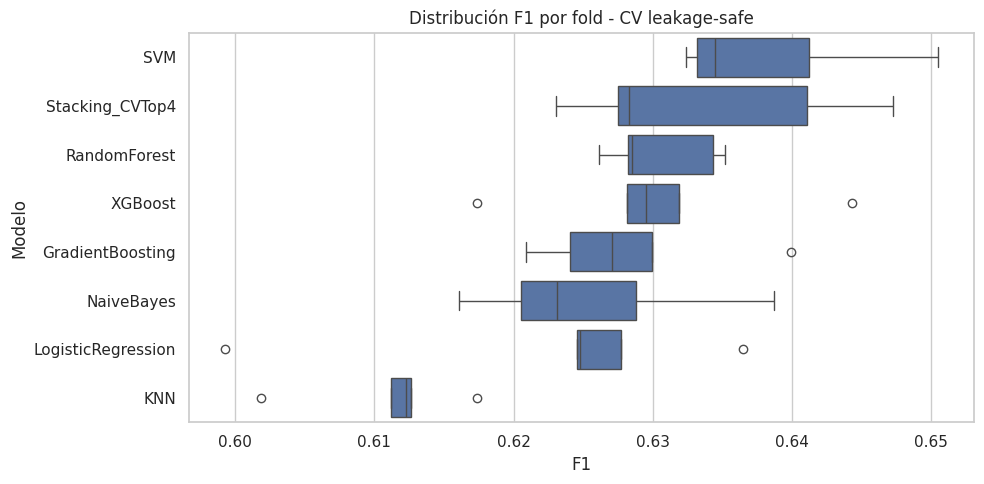

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=fold_df, x='F1', y='Modelo', order=cv_df['Modelo'], ax=ax)
ax.set_title('Distribución F1 por fold - CV leakage-safe')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_f1_boxplot.png', dpi=140, bbox_inches='tight')
plt.show()

## 4. ANOVA y Tukey para selección de los 3 mejores

Se aplica ANOVA de una vía sobre los F1 por fold para evaluar si existen diferencias significativas entre modelos.

- **H0:** los modelos tienen el mismo F1 medio en CV.
- **H1:** al menos un modelo tiene un F1 medio diferente.
- Si `p < 0.05`, Tukey HSD permite identificar pares con diferencias estadísticamente significativas.

La selección práctica combina evidencia estadística y rendimiento: `CV_F1_mean`, `CV_ROC_AUC_mean`, desviación estándar de F1, brecha train-CV y resultado de Tukey. El test no participa en esta decisión.


In [7]:
groups = [group['F1'].values for _, group in fold_df.groupby('Modelo')]
anova_stat, anova_p = stats.f_oneway(*groups)
print(f'ANOVA F={anova_stat:.4f}, p-value={anova_p:.6f}')

tukey = pairwise_tukeyhsd(endog=fold_df['F1'], groups=fold_df['Modelo'], alpha=0.05)
print(tukey)

top3_names = cv_df.head(3)['Modelo'].tolist()
print('Top 3 seleccionados por F1 medio de CV:', top3_names)

with open(OUTPUT_DIR / 'anova_tukey.txt', 'w', encoding='utf-8') as f:
    f.write(f'ANOVA F={anova_stat:.6f}, p-value={anova_p:.8f}\n\n')
    f.write(str(tukey))
    f.write(f'\n\nTop 3 por CV F1: {top3_names}\n')

ANOVA F=4.2755, p-value=0.001959
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1             group2       meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------
  GradientBoosting                KNN  -0.0173 0.0698 -0.0354 0.0008  False
  GradientBoosting LogisticRegression  -0.0058 0.9642  -0.024 0.0123  False
  GradientBoosting         NaiveBayes  -0.0029 0.9994 -0.0211 0.0152  False
  GradientBoosting       RandomForest   0.0021 0.9999  -0.016 0.0202  False
  GradientBoosting                SVM     0.01 0.6362 -0.0082 0.0281  False
  GradientBoosting    Stacking_CVTop4   0.0051 0.9835 -0.0131 0.0232  False
  GradientBoosting            XGBoost   0.0019    1.0 -0.0163   0.02  False
               KNN LogisticRegression   0.0115 0.4651 -0.0066 0.0296  False
               KNN         NaiveBayes   0.0144 0.2046 -0.0038 0.0325  False
               KNN       RandomForest   0.0194 0.0291  

In [8]:
selection_rationale = cv_df.loc[:, [
    'Modelo', 'CV_f1_mean', 'CV_f1_std', 'CV_roc_auc_mean', 'CV_roc_auc_std', 'Train_F1_mean', 'Gap_Train_CV_F1'
]].copy()
selection_rationale['Seleccionado_top3'] = selection_rationale['Modelo'].isin(top3_names)
selection_rationale.to_csv(OUTPUT_DIR / 'seleccion_top3_cv_anova_tukey.csv', index=False)

print('Justificación de selección:')
print('- Se ordena por CV_F1_mean porque F1 es la métrica principal ante desbalance.')
print('- CV_ROC_AUC_mean se usa como soporte de capacidad discriminativa.')
print('- CV_f1_std y Gap_Train_CV_F1 controlan estabilidad y sobreajuste.')
print('- Tukey informa si las diferencias son estadísticamente significativas; si varios modelos son equivalentes, se prioriza estabilidad y simplicidad.')
display(selection_rationale.round(4))


Justificación de selección:
- Se ordena por CV_F1_mean porque F1 es la métrica principal ante desbalance.
- CV_ROC_AUC_mean se usa como soporte de capacidad discriminativa.
- CV_f1_std y Gap_Train_CV_F1 controlan estabilidad y sobreajuste.
- Tukey informa si las diferencias son estadísticamente significativas; si varios modelos son equivalentes, se prioriza estabilidad y simplicidad.


,Modelo,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Train_F1_mean,Gap_Train_CV_F1,Seleccionado_top3
1,SVM,0.6384,0.0068,0.8289,0.0079,0.6645,0.0262,True
7,Stacking_CVTop4,0.6334,0.0092,0.8647,0.0067,0.7569,0.1235,True
4,RandomForest,0.6305,0.0036,0.8656,0.0063,0.7299,0.0995,True
6,XGBoost,0.6302,0.0086,0.8689,0.0064,0.6474,0.0171,False
5,GradientBoosting,0.6284,0.0065,0.8682,0.0061,0.6461,0.0177,False
3,NaiveBayes,0.6254,0.0078,0.8443,0.0060,0.6259,0.0004,False
0,LogisticRegression,0.6226,0.0124,0.8550,0.0071,0.6258,0.0033,False
2,KNN,0.6111,0.0051,0.8397,0.0041,0.6761,0.0650,False


## 5. Hiperparametrización de los 3 mejores

Se aplican tres estrategias a cada modelo seleccionado:

1. **GridSearchCV:** prueba combinaciones discretas definidas por criterio experto.
2. **Optuna:** usa búsqueda bayesiana TPE para explorar hiperparámetros prometedores.
3. **Algoritmo genético (`GASearchCV`):** evoluciona una población de configuraciones mediante selección, cruce y mutación. Para mantener el notebook ejecutable, esta búsqueda usa una muestra estratificada reproducible y CV interna de 2 folds; luego el candidato seleccionado se reajusta con el 70% completo antes del test final.

La selección final se hace con F1 de CV interno ajustado por sobreajuste. El test sigue reservado para la evaluación final. Stacking, si compite, fue construido con los 4 mejores modelos por F1 de CV, nunca por F1 de test.

Regla de control: el modelo desplegable debe cumplir `abs(F1_train - F1_test) <= 0.05`. Para empujar esa condición sin contaminar el test, se penalizan candidatos cuya brecha `F1_train_CV - F1_validacion_CV` supere 5 puntos porcentuales durante la optimización interna.


In [ ]:
MAX_F1_GAP = 0.05
GAP_PENALTY_WEIGHT = 2.0

def adjusted_cv_score(cv_f1, train_f1):
    gap = max(0.0, train_f1 - cv_f1)
    penalty = max(0.0, gap - MAX_F1_GAP) * GAP_PENALTY_WEIGHT
    return cv_f1 - penalty

param_grids = {
    'LogisticRegression': {
        'model__C': [0.05, 0.1, 0.3, 1.0],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs'],
    },
    'SVM': {
        'model__C': [0.5, 1.0, 2.0],
        'model__gamma': ['scale', 0.01],
        'model__kernel': ['rbf'],
    },
    'KNN': {
        'model__n_neighbors': [7, 11, 17],
        'model__weights': ['uniform', 'distance'],
    },
    'NaiveBayes': {'model__var_smoothing': [1e-9, 1e-8, 1e-7]},
    'RandomForest': {
        'model__n_estimators': [160, 220],
        'model__max_depth': [4, 6, 8],
        'model__min_samples_leaf': [20, 50, 80],
        'model__min_samples_split': [40, 100],
    },
    'GradientBoosting': {
        'model__n_estimators': [80, 120, 140],
        'model__learning_rate': [0.04, 0.06],
        'model__max_depth': [1, 2],
        'model__min_samples_leaf': [20],
    },
    'XGBoost': {
        'model__n_estimators': [100, 140],
        'model__max_depth': [1, 2],
        'model__learning_rate': [0.04, 0.06],
        'model__min_child_weight': [10],
        'model__reg_lambda': [8],
        'model__reg_alpha': [0.5],
    },
    'Stacking_CVTop4': {
        'model__final_estimator__C': [0.1, 1.0, 3.0],
    },
}

def suggest_estimator(name, trial):
    if name == 'LogisticRegression':
        return LogisticRegression(C=trial.suggest_float('C', 0.05, 5.0, log=True), max_iter=1000, random_state=RANDOM_STATE)
    if name == 'SVM':
        return SVC(C=trial.suggest_float('C', 0.3, 4.0, log=True), gamma=trial.suggest_categorical('gamma', ['scale', 0.005, 0.02]), kernel='rbf', probability=True, random_state=RANDOM_STATE)
    if name == 'KNN':
        return KNeighborsClassifier(n_neighbors=trial.suggest_int('n_neighbors', 5, 21, step=2), weights=trial.suggest_categorical('weights', ['uniform', 'distance']))
    if name == 'NaiveBayes':
        return GaussianNB(var_smoothing=trial.suggest_float('var_smoothing', 1e-10, 1e-6, log=True))
    if name == 'RandomForest':
        leaf = trial.suggest_int('min_samples_leaf', 20, 90, step=10)
        return RandomForestClassifier(n_estimators=trial.suggest_int('n_estimators', 120, 240, step=40), max_depth=trial.suggest_int('max_depth', 3, 8), min_samples_leaf=leaf, min_samples_split=max(40, leaf * 2), random_state=RANDOM_STATE, n_jobs=-1)
    if name == 'GradientBoosting':
        return GradientBoostingClassifier(n_estimators=trial.suggest_int('n_estimators', 70, 150, step=20), learning_rate=trial.suggest_float('learning_rate', 0.03, 0.08), max_depth=trial.suggest_int('max_depth', 1, 2), min_samples_leaf=20, random_state=RANDOM_STATE)
    if name == 'XGBoost':
        return XGBClassifier(n_estimators=trial.suggest_int('n_estimators', 80, 160, step=40), max_depth=trial.suggest_int('max_depth', 1, 2), learning_rate=trial.suggest_float('learning_rate', 0.03, 0.08), min_child_weight=10, subsample=trial.suggest_float('subsample', 0.8, 1.0), colsample_bytree=trial.suggest_float('colsample_bytree', 0.8, 1.0), reg_lambda=8, reg_alpha=0.5, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=2)
    if name == 'Stacking_CVTop4':
        final_c = trial.suggest_float('final_C', 0.05, 5.0, log=True)
        return StackingClassifier(
            estimators=[(model_name, clone(base_models[model_name])) for model_name in top4_for_stacking],
            final_estimator=LogisticRegression(C=final_c, max_iter=1000, random_state=RANDOM_STATE),
            stack_method='predict_proba',
            cv=3,
            n_jobs=-1,
        )
    raise ValueError(name)

GA_CONFIG = {
    "population_size": 20,
    "generations": 15,
    "elitism": True,
    "crossover_probability": 0.7,
    "mutation_probability": 0.15,
    "criteria": "max",
}

# La búsqueda genética es real, pero se acota para que el notebook sea ejecutable en sustentación.
# La muestra es estratificada y reproducible; GridSearchCV y Optuna siguen usando el train completo.

genetic_param_grids = {
    'LogisticRegression': {
        'model__C': Continuous(0.05, 5.0),
    },
    'SVM': {
        'model__C': Continuous(0.3, 4.0),
        'model__gamma': Categorical(['scale', 0.005, 0.02]),
    },
    'KNN': {
        'model__n_neighbors': Integer(5, 21),
        'model__weights': Categorical(['uniform', 'distance']),
    },
    'NaiveBayes': {
        'model__var_smoothing': Continuous(1e-10, 1e-6, distribution='log-uniform'),
    },
    'RandomForest': {
        'model__n_estimators': Integer(120, 240),
        'model__max_depth': Integer(3, 8),
        'model__min_samples_leaf': Integer(20, 90),
        'model__min_samples_split': Integer(40, 120),
    },
    'GradientBoosting': {
        'model__n_estimators': Integer(70, 150),
        'model__learning_rate': Continuous(0.03, 0.08),
        'model__max_depth': Integer(1, 2),
        'model__min_samples_leaf': Integer(15, 30),
    },
    'XGBoost': {
        'model__n_estimators': Integer(80, 160),
        'model__max_depth': Integer(1, 2),
        'model__learning_rate': Continuous(0.03, 0.08),
        'model__subsample': Continuous(0.8, 1.0),
        'model__colsample_bytree': Continuous(0.8, 1.0),
    },
    'Stacking_CVTop4': {
        'model__final_estimator__C': Continuous(0.05, 5.0),
    },
}


Muestra estratificada para algoritmo genético: (3499, 21); clases {0: 2615, 1: 884}
Optimizando SVM con GridSearchCV...
Optimizando SVM con Optuna...
Optimizando SVM con GASearchCV...
Optimizando Stacking_CVTop4 con GridSearchCV...
Optimizando Stacking_CVTop4 con Optuna...
Optimizando Stacking_CVTop4 con GASearchCV...
Optimizando RandomForest con GridSearchCV...
Optimizando RandomForest con Optuna...
Optimizando RandomForest con GASearchCV...


,Modelo,Metodo,CV_F1,Train_CV_F1,Gap_Train_CV_F1,CV_F1_Ajustado,Params
2,SVM,GeneticAlgorithm,0.638902,0.653911,0.015009,0.638902,"{'model__C': 1.9839431146133644, 'model__gamma..."
1,SVM,Optuna,0.633610,0.666363,0.032753,0.633610,"{'C': 0.9776244319973124, 'gamma': 'scale'}"
0,SVM,GridSearchCV,0.633608,0.666948,0.033340,0.633608,"{'model__C': 1.0, 'model__gamma': 'scale', 'mo..."
7,RandomForest,Optuna,0.630909,0.654286,0.023377,0.630909,"{'min_samples_leaf': 40, 'n_estimators': 240, ..."
6,RandomForest,GridSearchCV,0.630019,0.648984,0.018965,0.630019,"{'model__max_depth': 6, 'model__min_samples_le..."
8,RandomForest,GeneticAlgorithm,0.624523,0.667812,0.043289,0.624523,"{'model__n_estimators': 126, 'model__max_depth..."
4,Stacking_CVTop4,Optuna,0.632700,0.698662,0.065962,0.600777,{'final_C': 0.06533369619026641}
3,Stacking_CVTop4,GridSearchCV,0.635658,0.763212,0.127554,0.480551,{'model__final_estimator__C': 1.0}
5,Stacking_CVTop4,GeneticAlgorithm,0.625239,0.793360,0.168121,0.388998,{'model__final_estimator__C': 1.0444910077713754}


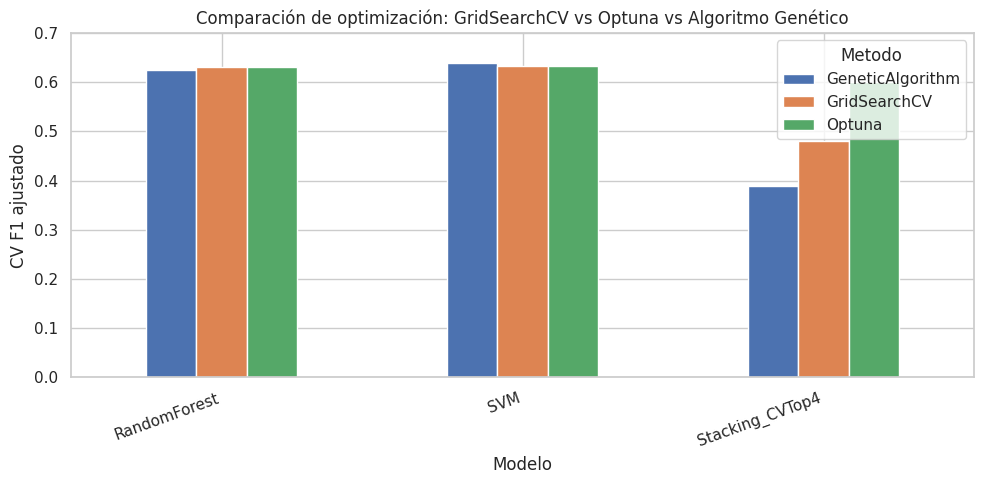

In [10]:
tuning_rows = []
best_candidates = []
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
ga_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

ga_df = train_original.groupby('finished', group_keys=False).apply(
    lambda part: part.sample(
        n=min(len(part), max(1, int(GA_CONFIG['sample_size'] * len(part) / len(train_original)))),
        random_state=RANDOM_STATE,
    )
)
X_ga = ga_df.drop(columns=['finished'])
y_ga = ga_df['finished']
print(f'Muestra estratificada para algoritmo genético: {X_ga.shape}; clases {y_ga.value_counts().sort_index().to_dict()}')

def register_candidate(modelo, metodo, cv_f1, train_f1, params, estimator):
    gap = train_f1 - cv_f1
    adjusted = adjusted_cv_score(cv_f1, train_f1)
    tuning_rows.append({
        'Modelo': modelo,
        'Metodo': metodo,
        'CV_F1': cv_f1,
        'Train_CV_F1': train_f1,
        'Gap_Train_CV_F1': gap,
        'CV_F1_Ajustado': adjusted,
        'Params': params,
    })
    best_candidates.append((f'{modelo}_{metodo}', adjusted, cv_f1, train_f1, estimator))

for name in top3_names:
    print(f'Optimizando {name} con GridSearchCV...')
    grid = GridSearchCV(
        estimator=build_pipeline(base_models[name]),
        param_grid=param_grids[name],
        scoring='f1',
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    grid_check = cross_validate(grid.best_estimator_, X_train, y_train, cv=inner_cv, scoring={'f1': 'f1'}, n_jobs=-1, return_train_score=True)
    register_candidate(
        name, 'GridSearchCV', grid_check['test_f1'].mean(), grid_check['train_f1'].mean(), grid.best_params_, grid.best_estimator_
    )

    print(f'Optimizando {name} con Optuna...')
    def objective(trial):
        estimator = suggest_estimator(name, trial)
        pipe = build_pipeline(estimator)
        scores = cross_validate(pipe, X_train, y_train, cv=inner_cv, scoring={'f1': 'f1'}, n_jobs=-1, return_train_score=True)
        return adjusted_cv_score(scores['test_f1'].mean(), scores['train_f1'].mean())

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=8, show_progress_bar=False)
    optuna_unfit = build_pipeline(suggest_estimator(name, study.best_trial))
    optuna_check = cross_validate(optuna_unfit, X_train, y_train, cv=inner_cv, scoring={'f1': 'f1'}, n_jobs=-1, return_train_score=True)
    optuna_pipe = clone(optuna_unfit).fit(X_train, y_train)
    register_candidate(
        name, 'Optuna', optuna_check['test_f1'].mean(), optuna_check['train_f1'].mean(), study.best_params, optuna_pipe
    )

    print(f'Optimizando {name} con GASearchCV...')
    ga = GASearchCV(
        estimator=build_pipeline(base_models[name]),
        cv=ga_cv,
        scoring='f1',
        population_size=GA_CONFIG['population_size'],
        generations=GA_CONFIG['generations'],
        elitism=GA_CONFIG['elitism'],
        crossover_probability=GA_CONFIG['crossover_probability'],
        mutation_probability=GA_CONFIG['mutation_probability'],
        param_grid=genetic_param_grids[name],
        criteria=GA_CONFIG['criteria'],
        n_jobs=1,
        verbose=False,
        keep_top_k=1,
    )
    ga.fit(X_ga, y_ga)
    ga_train_pred = ga.best_estimator_.predict(X_ga)
    ga_train_f1 = f1_score(y_ga, ga_train_pred, zero_division=0)
    register_candidate(
        name, 'GeneticAlgorithm', ga.best_score_, ga_train_f1, ga.best_params_, ga.best_estimator_
    )

tuning_df = pd.DataFrame(tuning_rows).sort_values('CV_F1_Ajustado', ascending=False)
tuning_df.to_csv(OUTPUT_DIR / 'optimizacion_top3.csv', index=False)
display(tuning_df)

opt_plot = tuning_df.pivot_table(index='Modelo', columns='Metodo', values='CV_F1_Ajustado', aggfunc='max')
ax = opt_plot.plot(kind='bar', figsize=(10, 5))
ax.set_title('Comparación de optimización: GridSearchCV vs Optuna vs Algoritmo Genético')
ax.set_ylabel('CV F1 ajustado')
ax.set_ylim(0, max(0.7, float(np.nanmax(opt_plot.values)) + 0.03))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'grid_optuna_genetic.png', dpi=140, bbox_inches='tight')
plt.show()


## Evaluación final en test reservado

In [11]:
best_name, best_adjusted_cv_f1, best_cv_f1, best_cv_train_f1, best_pipe_candidate = sorted(
    best_candidates,
    key=lambda item: item[1],
    reverse=True
)[0]

In [12]:
# ============================================================
# 1. Evaluación final en test reservado
# ============================================================
# Este modelo se entrena SOLO con train_original para evaluar generalización.
# El test reservado se usa una única vez para medir desempeño, no para seleccionar.
evaluation_pipe = clone(best_pipe_candidate).fit(X_train, y_train)

final_train_pred = evaluation_pipe.predict(X_train)
final_pred = evaluation_pipe.predict(X_test)
final_prob = evaluation_pipe.predict_proba(X_test)[:, 1]

final_train_f1 = f1_score(y_train, final_train_pred, zero_division=0)
final_test_f1 = f1_score(y_test, final_pred, zero_division=0)
final_train_test_gap = abs(final_train_f1 - final_test_f1)
gap_status = 'APROBADO' if final_train_test_gap <= MAX_F1_GAP else 'RECHAZADO'

final_metrics = {
    'Modelo': best_name,
    'CV_F1_Ajustado': best_adjusted_cv_f1,
    'CV_F1_seleccion': best_cv_f1,
    'CV_Train_F1_seleccion': best_cv_train_f1,
    'Train_F1_final': final_train_f1,
    'Accuracy': accuracy_score(y_test, final_pred),
    'Precision': precision_score(y_test, final_pred, zero_division=0),
    'Recall': recall_score(y_test, final_pred, zero_division=0),
    'F1': final_test_f1,
    'ROC_AUC': roc_auc_score(y_test, final_prob),
    'Gap_CV_Test_F1': best_cv_f1 - final_test_f1,
    'Gap_Train_Test_F1': final_train_test_gap,
    'Criterio_Gap_Train_Test_Max': MAX_F1_GAP,
    'Estado_Gap_Train_Test': gap_status,
}

metricas_finales = pd.DataFrame([final_metrics])
metricas_finales.to_csv(OUTPUT_DIR / 'metricas_finales.csv', index=False)

overfit_control = pd.DataFrame([{
    'Modelo': best_name,
    'Train_F1': final_train_f1,
    'CV_F1': best_cv_f1,
    'Test_F1': final_test_f1,
    'Gap_train_test': final_train_test_gap,
    'Estado_gap': gap_status,
}])
overfit_control.to_csv(OUTPUT_DIR / 'control_sobreajuste_final.csv', index=False)

comparativa_cv_test = cv_df.merge(
    metricas_finales[['Modelo', 'F1']].rename(columns={'F1': 'Test_F1'}),
    how='left',
    left_on='Modelo',
    right_on='Modelo',
)
comparativa_cv_test.to_csv(OUTPUT_DIR / 'comparativa_modelos_cv_test.csv', index=False)

cm = confusion_matrix(y_test, final_pred)
pd.DataFrame(
    cm,
    index=['real_0', 'real_1'],
    columns=['pred_0', 'pred_1']
).to_csv(OUTPUT_DIR / 'confusion_matrix_final.csv')

test_predictions = X_test.copy()
test_predictions['y_real'] = y_test.values
test_predictions['y_pred'] = final_pred
test_predictions['prob_finish'] = final_prob
test_predictions.to_csv(OUTPUT_DIR / 'predicciones_test_reservado.csv', index=False)

display(metricas_finales.round(4))
display(overfit_control.round(4))
display(pd.DataFrame(cm, index=['real_0', 'real_1'], columns=['pred_0', 'pred_1']))

if gap_status != 'APROBADO':
    raise RuntimeError(
        f'El modelo final no cumple la brecha máxima de F1 train-test: '
        f'{final_train_test_gap:.4f} > {MAX_F1_GAP:.4f}'
    )

print('Evaluación final completada sobre test reservado.')
print(f'Criterio de brecha F1 train-test: {gap_status} ({final_train_test_gap:.4f} <= {MAX_F1_GAP:.4f})')

,Modelo,CV_F1_Ajustado,CV_F1_seleccion,CV_Train_F1_seleccion,Train_F1_final,Accuracy,Precision,Recall,F1,ROC_AUC,Gap_CV_Test_F1,Gap_Train_Test_F1,Criterio_Gap_Train_Test_Max,Estado_Gap_Train_Test
0,SVM_GeneticAlgorithm,0.6389,0.6389,0.6539,0.6329,0.8019,0.6071,0.6129,0.61,0.8478,0.0289,0.0229,0.05,APROBADO


,Modelo,Train_F1,CV_F1,Test_F1,Gap_train_test,Estado_gap
0,SVM_GeneticAlgorithm,0.6329,0.6389,0.61,0.0229,APROBADO


,pred_0,pred_1
real_0,4616,715
real_1,698,1105


Evaluación final completada sobre test reservado.
Criterio de brecha F1 train-test: APROBADO (0.0229 <= 0.0500)


In [13]:
# ============================================================
# 2. Entrenamiento final para despliegue con el 100% de datos
# ============================================================
# Después de cerrar la evaluación, se reentrena el pipeline ganador usando
# train + test. Este modelo NO se vuelve a evaluar contra test, porque el test
# ya fue incorporado al entrenamiento final.
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

deployment_model = clone(best_pipe_candidate.named_steps['model'])
deployment_pipe = build_deployment_pipeline(deployment_model).fit(X_full, y_full)
assert 'sampler' not in deployment_pipe.named_steps, 'El pipeline de despliegue no debe incluir SMOTE/SMOTENC.'

# Backwards compatibility: las celdas posteriores siguen usando best_pipe.
best_pipe = deployment_pipe

joblib.dump(deployment_pipe, MODELS_DIR / 'best_model_pipe.pkl')
joblib.dump(evaluation_pipe, MODELS_DIR / 'best_model_pipe_evaluated_on_reserved_test.pkl')

deployment_metadata = {
    'modelo': best_name,
    'modelo_desplegado': str(MODELS_DIR / 'best_model_pipe.pkl'),
    'modelo_evaluado_test_reservado': str(MODELS_DIR / 'best_model_pipe_evaluated_on_reserved_test.pkl'),
    'n_train_evaluacion': int(len(X_train)),
    'n_test_reservado': int(len(X_test)),
    'n_entrenamiento_despliegue_100pct': int(len(X_full)),
    'features_entrada': list(X_full.columns),
    'pipeline_steps': list(deployment_pipe.named_steps.keys()),
    'incluye_smote': False,
    'target': 'finished',
    'test_f1_estimado_antes_reentrenamiento_100pct': float(final_test_f1),
    'test_roc_auc_estimado_antes_reentrenamiento_100pct': float(roc_auc_score(y_test, final_prob)),
    'nota_metodologica': (
        'La métrica de test corresponde al pipeline entrenado solo con train_original. '
        'El pipeline desplegado se reentrena después con train + test para aprovechar '
        'el 100% de los datos disponibles. No se reporta una nueva métrica de test '
        'sobre el modelo desplegado porque el test ya forma parte de su entrenamiento.'
    ),
}

with open(MODELS_DIR / 'deployment_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(deployment_metadata, f, indent=2, ensure_ascii=False)

print(f'Pipeline para despliegue guardado en {MODELS_DIR / "best_model_pipe.pkl"}')
print(f'Pipeline evaluado en test reservado guardado en {MODELS_DIR / "best_model_pipe_evaluated_on_reserved_test.pkl"}')
print('Pasos del pipeline desplegado:', list(deployment_pipe.named_steps.keys()))
print(f'Datos usados para despliegue: {X_full.shape}; clases {y_full.value_counts().sort_index().to_dict()}')

Pipeline para despliegue guardado en /home/creep/workshop/proyecto-mineria/models/best_model_pipe.pkl
Pipeline evaluado en test reservado guardado en /home/creep/workshop/proyecto-mineria/models/best_model_pipe_evaluated_on_reserved_test.pkl
Pasos del pipeline desplegado: ['drop_leakage', 'feature_engineering', 'winsorizer', 'selector', 'scaler', 'model']
Datos usados para despliegue: (23777, 21); clases {0: 17768, 1: 6009}


In [14]:
# Sanity check: el pipeline final acepta datos crudos, sin variables derivadas ni escaladas.
sample_raw = X_test.head(5).copy()
sample_pred = best_pipe.predict(sample_raw)
sample_prob = best_pipe.predict_proba(sample_raw)[:, 1]
display(pd.DataFrame({'pred': sample_pred, 'prob_finish': sample_prob}).round(4))

,pred,prob_finish
0,0,0.1515
1,0,0.1426
2,0,0.1118
3,0,0.1063
4,0,0.0966


## Veredicto metodológico

- La selección de modelos se hizo por F1 de CV sobre el 70% original.
- SMOTENC, winsorización y escalado se ajustaron dentro de cada fold.
- ANOVA/Tukey se aplicó sobre los F1 por fold de los modelos base y `Stacking_CVTop4`.
- Los 3 mejores por CV fueron optimizados con GridSearchCV, Optuna y algoritmo genético (`GASearchCV`).
- El stacking usa los 4 mejores modelos por F1 medio de CV, no por F1 de test.
- `SMOTENC` usa `sampling_strategy=0.5`: no iguala clases, limita la minoritaria al 50% de la mayoritaria.
- El test desbalanceado se usó al final absoluto para estimar generalización y auditar sobreajuste.
- Después de cerrar la evaluación en test reservado, el pipeline ganador se reentrenó con `train + test`, es decir, con el 100% de los datos disponibles.
- El modelo desplegado es `models/best_model_pipe.pkl`, entrenado con el 100% de los datos.
- La métrica de test reportada corresponde al modelo entrenado solo con train; no se reevalúa el modelo desplegado sobre test porque ese test ya fue incorporado al entrenamiento final.
- El pipeline final contiene preparación + balanceo de entrenamiento + escalado + modelo y acepta datos crudos en inferencia.